# 06b — Eksperimen Arsitektur LSTM

In [1]:
import os
import json
import time

import numpy as np
import pandas as pd
import joblib
import tensorflow as tf

from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, BatchNormalization, Input,
    Bidirectional, Attention, GlobalAveragePooling1D, Concatenate,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


### Load dataset & metadata 

In [2]:
data = np.load("../artifacts/dataset_sequences.npz")

X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]

print(X_train.shape, X_val.shape, X_test.shape)

metadata = joblib.load("../artifacts/dataset_metadata.pkl")
WINDOW_SIZE  = metadata["window_size"]
feature_cols = metadata["feature_cols"]
target_col   = metadata["target_col"]
n_features   = metadata["n_features"]

scaler_X = joblib.load("../artifacts/scaler_X.pkl")
scaler_y = joblib.load("../artifacts/scaler_y.pkl")

os.makedirs("../models", exist_ok=True)
os.makedirs("../artifacts", exist_ok=True)


(216981, 24, 30) (43963, 24, 30) (28428, 24, 30)


### Fungsi evaluasi & runner training 

In [3]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    nrmse = rmse / (np.max(y_true) - np.min(y_true))
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "NRMSE": nrmse, "R2": r2}


def inverse_y(y):
    return scaler_y.inverse_transform(np.asarray(y).reshape(-1, 1))


def run_experiment(name, build_fn, epochs=50, batch_size=64, patience=7, verbose=0):
    """Latih 1 varian model, evaluasi di train/val/test, kembalikan dict hasil."""
    tf.keras.backend.clear_session()
    model = build_fn()

    ckpt_path = f"../models/lstm_{name}.keras"

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(2, patience // 2), min_lr=1e-6, verbose=0),
        ModelCheckpoint(filepath=ckpt_path, monitor="val_loss", save_best_only=True, verbose=0),
    ]

    t0 = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=verbose,
    )
    train_time = time.time() - t0

    best_model = load_model(ckpt_path)

    y_train_pred = inverse_y(best_model.predict(X_train, verbose=0))
    y_val_pred   = inverse_y(best_model.predict(X_val, verbose=0))
    y_test_pred  = inverse_y(best_model.predict(X_test, verbose=0))

    y_train_true = inverse_y(y_train)
    y_val_true   = inverse_y(y_val)
    y_test_true  = inverse_y(y_test)

    metrics = {
        "name": name,
        "params": best_model.count_params(),
        "epochs_run": len(history.history["loss"]),
        "train_time_sec": round(train_time, 1),
        "train": evaluate_regression(y_train_true, y_train_pred),
        "val": evaluate_regression(y_val_true, y_val_pred),
        "test": evaluate_regression(y_test_true, y_test_pred),
    }

    preds = {
        "y_train_true": y_train_true, "y_train_pred": y_train_pred,
        "y_val_true": y_val_true, "y_val_pred": y_val_pred,
        "y_test_true": y_test_true, "y_test_pred": y_test_pred,
    }

    return metrics, preds, history, ckpt_path


## Varian arsitektur yang dibandingkan

| Nama | Ide |
|---|---|
| `baseline` | Arsitektur asli notebook 06 (LSTM 128 -> LSTM 64 -> Dense 32 -> Dense 1) sebagai pembanding |
| `gru` | Ganti LSTM dengan GRU (parameter lebih sedikit, kadang lebih cepat konvergen) |
| `bidirectional` | Bidirectional LSTM di layer pertama |
| `attention` | LSTM + attention pooling di atas seluruh output sequence (bukan cuma ambil timestep terakhir) |
| `deep_wide` | Lebih dalam & lebih lebar + L2 regularization (cek apakah kapasitas lebih besar membantu atau malah overfit) |
| `light_reg` | Lebih kecil + dropout & L2 lebih kuat (cek apakah model lebih sederhana justru lebih general ke test set) |


In [4]:
input_shape = (X_train.shape[1], X_train.shape[2])


def build_baseline():
    model = Sequential([
        Input(shape=input_shape),
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        BatchNormalization(),
        LSTM(64),
        Dropout(0.2),
        BatchNormalization(),
        Dense(32, activation="relu"),
        Dropout(0.1),
        Dense(1),
    ])
    model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
    return model


def build_gru():
    model = Sequential([
        Input(shape=input_shape),
        GRU(128, return_sequences=True),
        Dropout(0.2),
        BatchNormalization(),
        GRU(64),
        Dropout(0.2),
        BatchNormalization(),
        Dense(32, activation="relu"),
        Dropout(0.1),
        Dense(1),
    ])
    model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
    return model


def build_bidirectional():
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(96, return_sequences=True)),
        Dropout(0.2),
        BatchNormalization(),
        Bidirectional(LSTM(48)),
        Dropout(0.2),
        BatchNormalization(),
        Dense(32, activation="relu"),
        Dropout(0.1),
        Dense(1),
    ])
    model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
    return model


def build_attention():
    inputs = Input(shape=input_shape)
    x = LSTM(128, return_sequences=True)(inputs)
    x = Dropout(0.2)(x)
    x = BatchNormalization()(x)
    x = LSTM(64, return_sequences=True)(x)
    x = Dropout(0.2)(x)

    # self-attention sederhana: setiap timestep "memilih" seberapa penting
    # dirinya sendiri relatif terhadap seluruh window, lalu di-pool.
    attn_out = Attention()([x, x])
    pooled = GlobalAveragePooling1D()(attn_out)

    x = Dense(32, activation="relu")(pooled)
    x = Dropout(0.1)(x)
    outputs = Dense(1)(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
    return model


def build_deep_wide():
    model = Sequential([
        Input(shape=input_shape),
        LSTM(192, return_sequences=True, kernel_regularizer=l2(1e-5)),
        Dropout(0.25),
        BatchNormalization(),
        LSTM(96, return_sequences=True, kernel_regularizer=l2(1e-5)),
        Dropout(0.25),
        BatchNormalization(),
        LSTM(48),
        Dropout(0.2),
        BatchNormalization(),
        Dense(64, activation="relu"),
        Dropout(0.15),
        Dense(1),
    ])
    model.compile(optimizer=Adam(8e-4), loss="mse", metrics=["mae"])
    return model


def build_light_reg():
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(32, kernel_regularizer=l2(1e-4)),
        Dropout(0.3),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1),
    ])
    model.compile(optimizer=Adam(1e-3), loss="mse", metrics=["mae"])
    return model


VARIANTS = {
    "baseline": build_baseline,
    "gru": build_gru,
    "bidirectional": build_bidirectional,
    "attention": build_attention,
    "deep_wide": build_deep_wide,
    "light_reg": build_light_reg,
}


## Jalankan semua varian

Default `epochs=50` dengan `EarlyStopping(patience=7)` 

In [6]:
all_metrics = []
all_preds = {}
all_ckpts = {}

for name, build_fn in VARIANTS.items():
    print(f"\n=== Training varian: {name} ===")
    metrics, preds, history, ckpt_path = run_experiment(name, build_fn, epochs=15, batch_size=64, patience=7, verbose=1)
    all_metrics.append(metrics)
    all_preds[name] = preds
    all_ckpts[name] = ckpt_path
    print(f"Test  -> MAE: {metrics['test']['MAE']:.3f} | RMSE: {metrics['test']['RMSE']:.3f} | R2: {metrics['test']['R2']:.4f}")



=== Training varian: baseline ===
Epoch 1/15
3391/3391 ━━━━━━━━━━━━━━━━━━━━ 73s 21ms/step - loss: 0.0211 - mae: 0.0712 - val_loss: 5.2881e-04 - val_mae: 0.0178 - learning_rate: 0.0010
Epoch 2/15
3391/3391 ━━━━━━━━━━━━━━━━━━━━ 69s 20ms/step - loss: 0.0010 - mae: 0.0212 - val_loss: 2.8281e-04 - val_mae: 0.0119 - learning_rate: 0.0010
Epoch 3/15
3391/3391 ━━━━━━━━━━━━━━━━━━━━ 70s 21ms/step - loss: 7.3554e-04 - mae: 0.0178 - val_loss: 2.8727e-04 - val_mae: 0.0112 - learning_rate: 0.0010
Epoch 4/15
3391/3391 ━━━━━━━━━━━━━━━━━━━━ 73s 21ms/step - loss: 5.9852e-04 - mae: 0.0158 - val_loss: 2.4971e-04 - val_mae: 0.0119 - learning_rate: 0.0010
Epoch 5/15
3391/3391 ━━━━━━━━━━━━━━━━━━━━ 70s 21ms/step - loss: 4.9206e-04 - mae: 0.0143 - val_loss: 1.5560e-04 - val_mae: 0.0084 - learning_rate: 0.0010
Epoch 6/15
3391/3391 ━━━━━━━━━━━━━━━━━━━━ 71s 21ms/step - loss: 4.1086e-04 - mae: 0.0129 - val_loss: 1.7233e-04 - val_mae: 0.0085 - learning_rate: 0.0010
Epoch 7/15
3391/3391 ━━━━━━━━━━━━━━━━━━━━ 71s 21m

### Ringkasan perbandingan semua varian

In [7]:
def metrics_to_row(m):
    return {
        "variant": m["name"],
        "params": m["params"],
        "epochs_run": m["epochs_run"],
        "train_time_sec": m["train_time_sec"],
        "train_MAE": m["train"]["MAE"], "train_R2": m["train"]["R2"],
        "val_MAE": m["val"]["MAE"], "val_RMSE": m["val"]["RMSE"], "val_R2": m["val"]["R2"],
        "test_MAE": m["test"]["MAE"], "test_RMSE": m["test"]["RMSE"], "test_R2": m["test"]["R2"],
    }

comparison_df = pd.DataFrame([metrics_to_row(m) for m in all_metrics]).sort_values("test_MAE")
comparison_df.to_csv("../models/lstm_variant_comparison.csv", index=False)
comparison_df


,variant,params,epochs_run,train_time_sec,train_MAE,train_R2,val_MAE,val_RMSE,val_R2,test_MAE,test_RMSE,test_R2
0,baseline,133697,15,1224.5,4.409833,0.990299,4.163210,7.831123,0.989120,5.818821,15.527293,0.876957
2,bidirectional,194369,15,1384.9,4.443259,0.990920,4.367179,8.185001,0.988115,6.040917,15.990081,0.869513
3,attention,133441,15,1742.1,5.320629,0.988777,4.720702,8.189939,0.988100,6.254446,14.793936,0.888305
1,gru,101569,15,1414.1,5.450678,0.987269,4.990503,8.716441,0.986521,6.256970,13.949340,0.900694
4,deep_wide,314625,15,2886.4,6.503304,0.977627,5.806566,9.299579,0.984657,7.170621,14.582032,0.891482
5,light_reg,37537,15,895.7,10.841715,0.953453,9.083708,13.378845,0.968245,10.178338,15.889161,0.871155


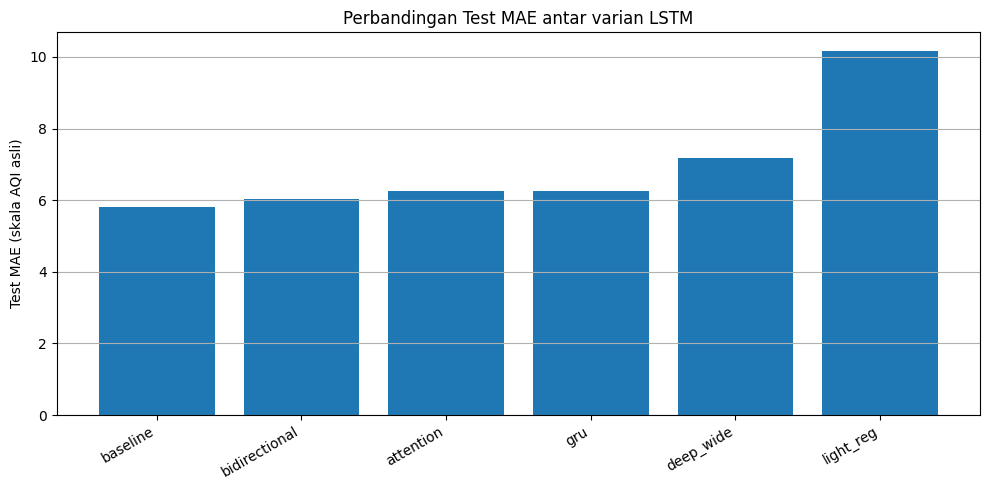

In [8]:
plt.figure(figsize=(10, 5))
plt.bar(comparison_df["variant"], comparison_df["test_MAE"])
plt.ylabel("Test MAE (skala AQI asli)")
plt.title("Perbandingan Test MAE antar varian LSTM")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()


## Optuna: tuning hyperparameter untuk varian terpilih


In [ ]:
import optuna

class KerasPruningCallback(tf.keras.callbacks.Callback):
    def __init__(self, trial, monitor="val_loss"):
        super().__init__()
        self.trial = trial
        self.monitor = monitor

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        value = logs.get(self.monitor)
        if value is None:
            return
        self.trial.report(value, step=epoch)
        if self.trial.should_prune():
            raise optuna.TrialPruned(f"Trial pruned at epoch {epoch} ({self.monitor}={value:.5f})")


N_TRIALS = 20          
MAX_EPOCHS_PER_TRIAL = 30


def build_from_trial(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    cell_type = trial.suggest_categorical("cell_type", ["LSTM", "GRU"])
    units_first = trial.suggest_categorical("units_first", [32, 64, 96, 128, 192])
    dropout = trial.suggest_float("dropout", 0.1, 0.4)
    l2_reg = trial.suggest_float("l2_reg", 1e-6, 1e-3, log=True)
    dense_units = trial.suggest_categorical("dense_units", [16, 32, 64])
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)

    RNN = LSTM if cell_type == "LSTM" else GRU

    model = Sequential()
    model.add(Input(shape=input_shape))

    units = units_first
    for i in range(n_layers):
        return_seq = i < n_layers - 1
        model.add(RNN(units, return_sequences=return_seq, kernel_regularizer=l2(l2_reg)))
        model.add(Dropout(dropout))
        if return_seq:
            model.add(BatchNormalization())
        units = max(16, units // 2)

    model.add(Dense(dense_units, activation="relu"))
    model.add(Dropout(dropout / 2))
    model.add(Dense(1))

    model.compile(optimizer=Adam(lr), loss="mse", metrics=["mae"])
    return model


def objective(trial):
    tf.keras.backend.clear_session()

    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    model = build_from_trial(trial)

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=0),
        KerasPruningCallback(trial, "val_loss"),
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=MAX_EPOCHS_PER_TRIAL,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=0,
    )

    return min(history.history["val_loss"])


study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=5),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("Best val_loss:", study.best_value)
print("Best params:", study.best_params)


[I 2026-07-02 08:48:25,622] A new study created in memory with name: no-name-1918efa2-bffe-4914-b6d9-76d973994366
  0%|          | 0/20 [18:16<?, ?it/s]

[W 2026-07-02 09:06:42,367] Trial 0 failed with parameters: {'batch_size': 32, 'n_layers': 2, 'cell_type': 'GRU', 'units_first': 96, 'dropout': 0.21097263654706472, 'l2_reg': 1.2748371732136684e-05, 'dense_units': 16, 'lr': 0.000133522422946526} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Yosua Triantara\miniconda3\envs\foodseg\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Yosua Triantara\AppData\Local\Temp\ipykernel_36756\2584039948.py", line 68, in objective
    history = model.fit(
              ^^^^^^^^^^
  File "c:\Users\Yosua Triantara\miniconda3\envs\foodseg\Lib\site-packages\keras\src\utils\traceback_utils.py", line 117, in error_handler
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Yosua Triantara\miniconda3\envs\foodseg\Lib\site-packages\keras\src\backend\tensorflow\trainer.py

KeyboardInterrupt: 

In [ ]:
joblib.dump(study.best_params, "../models/lstm_optuna_best_params.pkl")
study.trials_dataframe().to_csv("../models/lstm_optuna_trials.csv", index=False)

optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.show()


### Latih ulang model dengan hyperparameter terbaik dari Optuna, evaluasi penuh (train/val/test)

In [ ]:
def build_best_from_optuna():
    class _T:
        def __init__(self, params):
            self.params = params
        def suggest_int(self, name, *a, **k): return self.params[name]
        def suggest_categorical(self, name, *a, **k): return self.params[name]
        def suggest_float(self, name, *a, **k): return self.params[name]

    return build_from_trial(_T(study.best_params))


best_batch_size = study.best_params["batch_size"]

optuna_metrics, optuna_preds, optuna_history, optuna_ckpt = run_experiment(
    "optuna_best", build_best_from_optuna, epochs=60, batch_size=best_batch_size, patience=8, verbose=1
)

print(json.dumps(optuna_metrics, indent=2, default=float))


## Pilih model final & simpan artefak

In [11]:
all_metrics.append(optuna_metrics)
all_preds["optuna_best"] = optuna_preds
all_ckpts["optuna_best"] = optuna_ckpt

final_comparison = pd.DataFrame([metrics_to_row(m) for m in all_metrics]).sort_values("test_MAE")
final_comparison.to_csv("../models/lstm_variant_comparison_final.csv", index=False)
final_comparison


NameError: name 'optuna_metrics' is not defined

In [13]:
best_name = comparison_df.iloc[0]["variant"]
print(f"Model LSTM terbaik: {best_name}")

best_preds = all_preds[best_name]
best_ckpt = all_ckpts[best_name]

# salin jadi model final
import shutil
shutil.copy(best_ckpt, "../models/best_lstm.keras")

residual_train = (best_preds["y_train_true"] - best_preds["y_train_pred"]).ravel()
residual_val   = (best_preds["y_val_true"]   - best_preds["y_val_pred"]).ravel()
residual_test  = (best_preds["y_test_true"]  - best_preds["y_test_pred"]).ravel()

np.savez_compressed(
    "../artifacts/lstm_predictions_best.npz",
    y_train_true=best_preds["y_train_true"], y_train_pred=best_preds["y_train_pred"],
    y_val_true=best_preds["y_val_true"], y_val_pred=best_preds["y_val_pred"],
    y_test_true=best_preds["y_test_true"], y_test_pred=best_preds["y_test_pred"],
    residual_train=residual_train, residual_val=residual_val, residual_test=residual_test,
)

joblib.dump({"best_variant": best_name}, "../models/lstm_best_variant.pkl")

print("Artefak model LSTM terbaik tersimpan -> ../models/best_lstm.keras")
print("Prediksi tersimpan -> ../artifacts/lstm_predictions_best.npz")
print("Lanjutkan ke 07b_XGBoost_Experiments.ipynb")


Model LSTM terbaik: baseline
Artefak model LSTM terbaik tersimpan -> ../models/best_lstm.keras
Prediksi tersimpan -> ../artifacts/lstm_predictions_best.npz
Lanjutkan ke 07b_XGBoost_Experiments.ipynb
